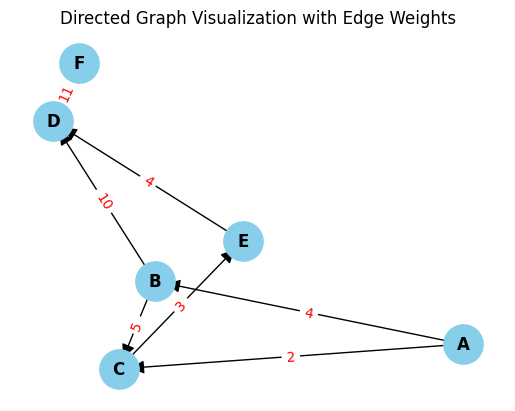

In [1]:
#1. Directed Graph Visualization
import networkx as nx
import matplotlib.pyplot as plt

# Sample weighted directed graph edges: (source, target, weight)
edges = [
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 10),
    ('C', 'E', 3),
    ('E', 'D', 4),
    ('D', 'F', 11)
]

# Create directed graph
G = nx.DiGraph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Position nodes using spring layout
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800)

# Draw edges with arrowheads to show direction
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='black')

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw edge labels showing weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Set plot title and hide axes
plt.title("Directed Graph Visualization with Edge Weights")
plt.axis('off')
plt.show()


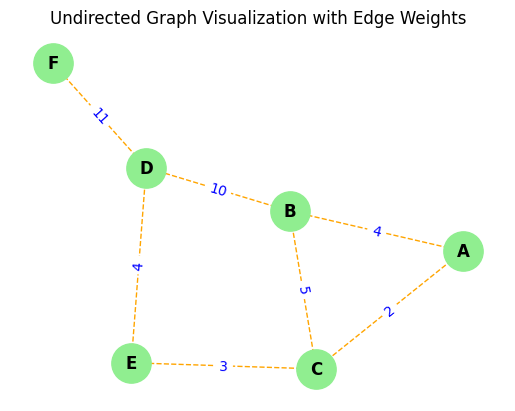

In [2]:
#2. Undirected Graph Visualization
import networkx as nx
import matplotlib.pyplot as plt

# Same edges as before, but we'll create an undirected graph
edges = [
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 10),
    ('C', 'E', 3),
    ('E', 'D', 4),
    ('D', 'F', 11)
]

# Create undirected graph
G_undirected = nx.Graph()
for u, v, w in edges:
    G_undirected.add_edge(u, v, weight=w)

# Position nodes using spring layout (same seed for consistency)
pos = nx.spring_layout(G_undirected, seed=42)

# Draw nodes with a different color from directed graph (e.g., light green)
nx.draw_networkx_nodes(G_undirected, pos, node_color='lightgreen', node_size=800)

# Draw edges with dashed style and a different color to distinguish from directed graph
nx.draw_networkx_edges(G_undirected, pos, edge_color='orange', style='dashed')

# Draw node labels
nx.draw_networkx_labels(G_undirected, pos, font_size=12, font_weight='bold')

# Draw edge labels (weights)
edge_labels = nx.get_edge_attributes(G_undirected, 'weight')
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels, font_color='blue')

plt.title("Undirected Graph Visualization with Edge Weights")
plt.axis('off')
plt.show()


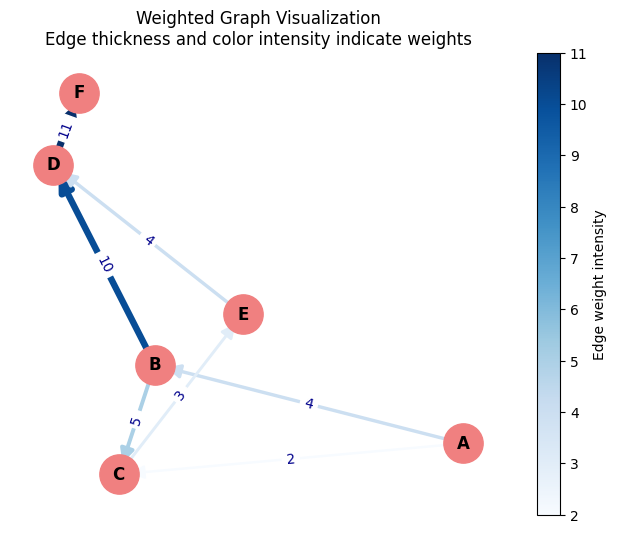

In [7]:
#3. Weighted Graph Visualization
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

edges = [
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 10),
    ('C', 'E', 3),
    ('E', 'D', 4),
    ('D', 'F', 11)
]

G = nx.DiGraph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(weights)
min_weight = min(weights)

edge_thickness = [1 + (w / max_weight) * 4 for w in weights]

fig, ax = plt.subplots(figsize=(8,6))  # create figure and axes explicitly

nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=800, ax=ax)

norm = mpl.colors.Normalize(vmin=min_weight, vmax=max_weight)
cmap = plt.cm.Blues

edges_collection = nx.draw_networkx_edges(
    G, pos,
    width=edge_thickness,
    edge_color=weights,
    edge_cmap=cmap,
    edge_vmin=min_weight,
    edge_vmax=max_weight,
    arrowsize=20,
    ax=ax
)

nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkblue', ax=ax)

ax.set_title("Weighted Graph Visualization\nEdge thickness and color intensity indicate weights")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Edge weight intensity")  # pass ax here

ax.axis('off')
plt.show()



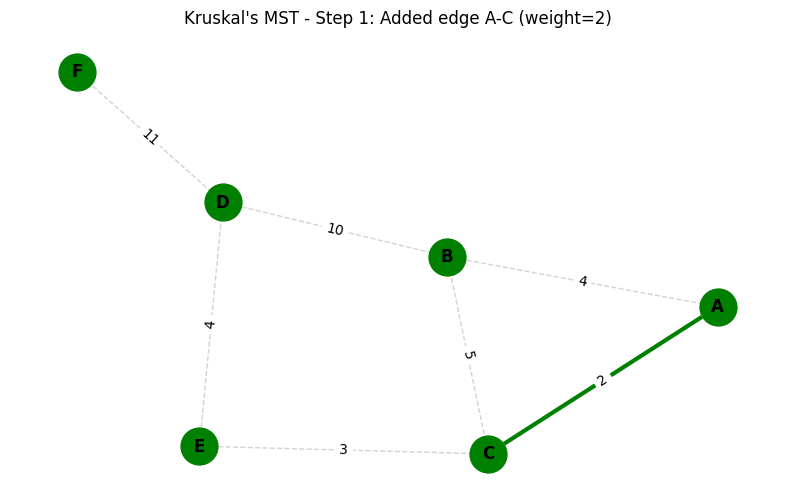

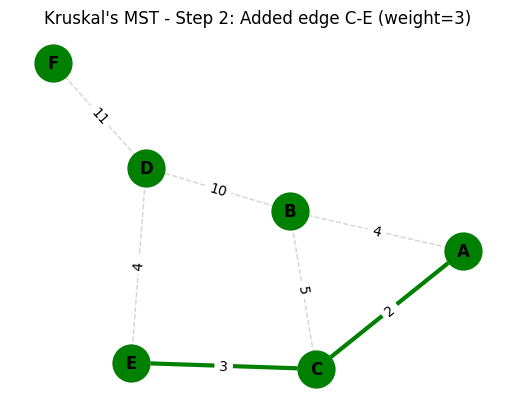

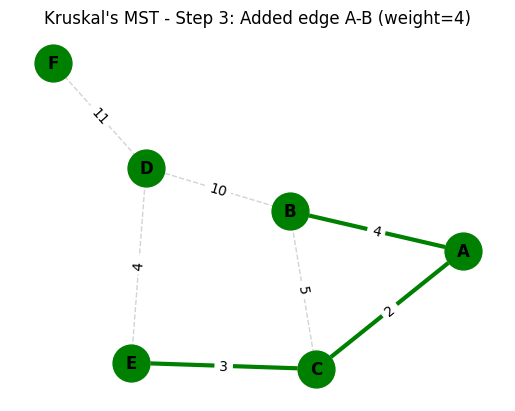

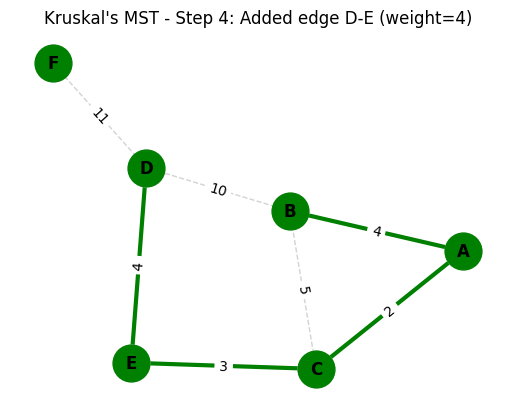

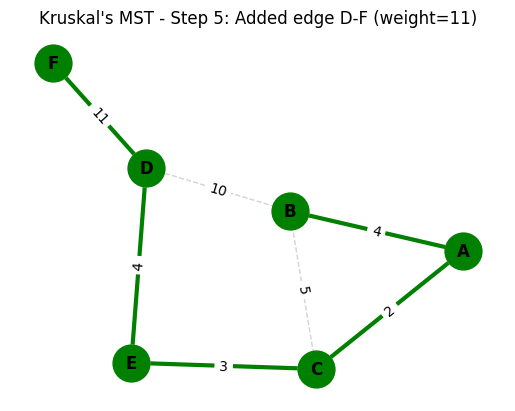

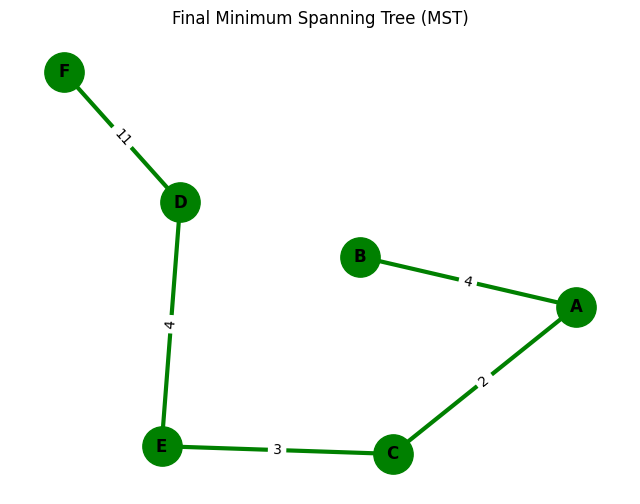

In [8]:
#4. Algorithm Implementation: Choose One
import networkx as nx
import matplotlib.pyplot as plt

# Sample weighted undirected graph edges
edges = [
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 10),
    ('C', 'E', 3),
    ('E', 'D', 4),
    ('D', 'F', 11)
]

# Create undirected weighted graph
G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=42)  # fixed layout for all plots

# Kruskal's MST algorithm implementation with visualization
def kruskal_mst(graph):
    mst = nx.Graph()
    mst.add_nodes_from(graph.nodes(data=True))

    # Sort edges by ascending weight
    edges_sorted = sorted(graph.edges(data=True), key=lambda x: x[2]['weight'])

    # Disjoint Set (Union-Find) helper
    parent = {node: node for node in graph.nodes()}

    def find(n):
        while parent[n] != n:
            n = parent[n]
        return n

    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
            return True
        return False

    plt.figure(figsize=(10, 6))
    step = 1

    for u, v, data in edges_sorted:
        if union(u, v):
            mst.add_edge(u, v, weight=data['weight'])

            plt.clf()
            # Draw all nodes and edges faded
            nx.draw_networkx_nodes(graph, pos, node_color='lightgrey', node_size=700)
            nx.draw_networkx_edges(graph, pos, edge_color='lightgrey', style='dashed')
            nx.draw_networkx_labels(graph, pos, font_size=12, font_weight='bold')

            # Highlight MST edges and nodes
            nx.draw_networkx_nodes(mst, pos, node_color='green', node_size=700)
            nx.draw_networkx_edges(mst, pos, width=3, edge_color='green')

            edge_labels = nx.get_edge_attributes(graph, 'weight')
            nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

            plt.title(f"Kruskal's MST - Step {step}: Added edge {u}-{v} (weight={data['weight']})")
            plt.axis('off')
            plt.pause(1)  # pause 1 second to visualize each step
            step += 1

    plt.show()
    return mst

# Run the Kruskal MST visualization
mst = kruskal_mst(G)

# Final MST plot
plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(mst, pos, node_color='green', node_size=800)
nx.draw_networkx_edges(mst, pos, width=3, edge_color='green')
nx.draw_networkx_labels(mst, pos, font_size=12, font_weight='bold')
edge_labels = nx.get_edge_attributes(mst, 'weight')
nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels)
plt.title("Final Minimum Spanning Tree (MST)")
plt.axis('off')
plt.show()
